# Survival Analysis
Survival analysis is a fascinating branch of statistics that focuses on answering one simple, yet powerful question: "When will something happen?" Whether we're predicting when a customer will churn, when a machine part will fail, or how long an employee might stay at a company, survival analysis gives us the tools to model and understand time-to-event data — even when the event hasn’t happened yet for everyone.

What makes survival analysis unique is its ability to handle censored data — situations where we know that the event hasn’t occurred yet, but we don’t know exactly when (like a customer still active at the time of analysis). Unlike typical regression problems, where we predict a value like “number of days,” survival models focus on estimating the probability of survival beyond a given time, or the hazard (risk) of the event occurring at a specific moment. In this part of the sprint, we’ll explore these ideas and apply classical tools — like Kaplan-Meier curves and Cox regression — to real-world problems, all without needing deep learning.

### Survival analysis problem

Survival analysis is a set of statistical methods for analyzing the time it takes for an event of interest to happen. This “event” could be anything — a machine breaking down, a customer churning, or a patient relapsing. What sets survival analysis apart from standard regression is that it can handle incomplete data, i.e., when we don’t observe the event for all subjects. Real-world examples:

- Customer churn: How long until a customer stops using a service?
- Employee attrition: What is the expected time before an employee leaves?
- Warranty failure: How long until a product fails under warranty?
- Medical prognosis: What is the probability a patient survives 1 year after treatment?

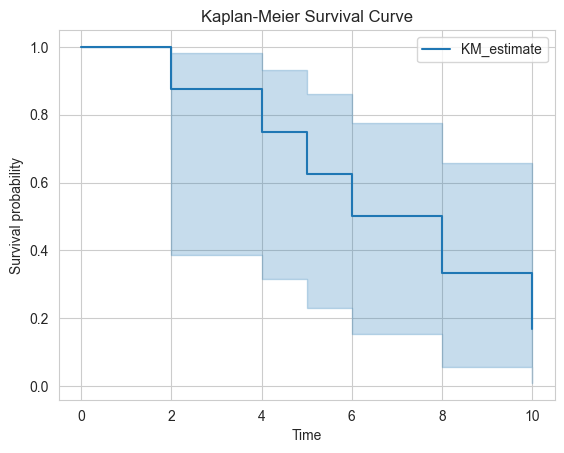

In [1]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

durations = [5, 6, 6, 2, 4, 8, 10, 10]
event_observed = [1, 0, 1, 1, 1, 1, 0, 1]  # 1 = event occurred, 0 = censored

kmf = KaplanMeierFitter()
kmf.fit(durations, event_observed)

# Plot survival curve
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time")
plt.ylabel("Survival probability")
plt.show()

Life tables summarize survival probabilities over fixed intervals (e.g., monthly). While less flexible than Kaplan-Meier, they're useful when time is grouped or you want a tabular summary. lifelines provides support for life tables using survival_table_from_events().

In [2]:
from lifelines.utils import survival_table_from_events

table = survival_table_from_events(durations, event_observed)
print(table.head())

          removed  observed  censored  entrance  at_risk
event_at                                                
0.0             0         0         0         8        8
2.0             1         1         0         0        8
4.0             1         1         0         0        7
5.0             1         1         0         0        6
6.0             2         1         1         0        5


In [3]:
import pandas as pd
import numpy as np
from lifelines.statistics import logrank_test

# -------------------------
# 1️⃣ Create dummy survival data
# -------------------------
np.random.seed(42)

n = 40

data = pd.DataFrame({
    "duration": np.concatenate([
        np.random.exponential(scale=10, size=n//2),  # Group A: shorter survival
        np.random.exponential(scale=18, size=n//2)   # Group B: longer survival
    ]),
    "event": np.random.binomial(1, 0.7, size=n),     # 1 = event observed, 0 = censored
    "group": ["A"] * (n//2) + ["B"] * (n//2)
})

data.head()

,duration,event,group
0,4.692681,1,A
1,30.101214,1,A
2,13.167457,1,A
3,9.129426,0,A
4,1.696249,1,A


In [4]:
from lifelines.statistics import logrank_test

# Compare survival of group A vs group B
results = logrank_test(
    data[data['group'] == 'A']['duration'],
    data[data['group'] == 'B']['duration'],
    event_observed_A=data[data['group'] == 'A']['event'],
    event_observed_B=data[data['group'] == 'B']['event']
)
results.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           1.49 0.22      2.17

 **Kaplan-Meier Estimator (Non-parametric)**

The Kaplan-Meier estimator is great for visualizing survival probabilities and comparing groups, but it doesn’t allow for covariates (like age, gender, etc.). Still, it’s useful as a first step or a benchmark.

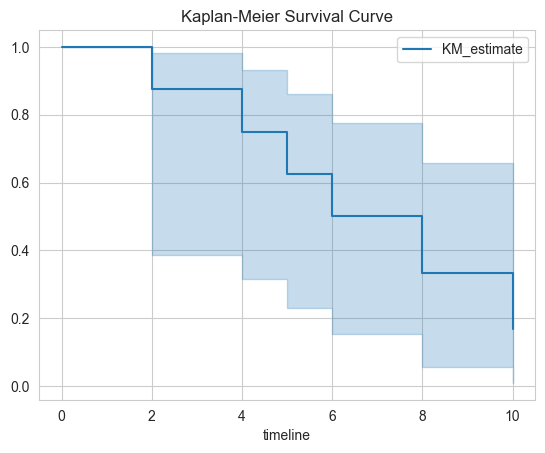

In [5]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Sample dataset
durations = [5, 6, 6, 2, 4, 8, 10, 10]
events = [1, 0, 1, 1, 1, 1, 0, 1]  # 1 = event occurred, 0 = censored

kmf = KaplanMeierFitter()
kmf.fit(durations, events)
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.show()

**Cox Proportional Hazards Model (Semi-parametric)**

The Cox model allows us to estimate the effect of covariates on survival time without making strong assumptions about the baseline hazard function.

In [6]:
from lifelines import CoxPHFitter
import pandas as pd

# Sample data
df = pd.DataFrame({
    'duration': [5, 6, 6, 2, 4, 8, 10, 10],
    'event':    [1, 0, 1, 1, 1, 1, 0, 1],
    'age':      [25, 45, 31, 50, 38, 40, 42, 36],
    'gender':   [1, 0, 1, 0, 1, 1, 0, 1]  # 1 = Female, 0 = Male
})

cph = CoxPHFitter()
cph.fit(df, duration_col='duration', event_col='event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 8 total observations, 2 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 8
number of events observed = 6
   partial log-likelihood = -8.59
         time fit was run = 2025-12-18 13:12:12 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
age        0.01      1.01      0.10           -0.19            0.21                0.83                1.24
gender     1.21      3.34      1.37           -1.48            3.89                0.23               48.89

           cmp to    z    p  -log2(p)
covariate                            
age          0.00 0.13 0.90      0.16
gender       0.00 0.88 0.38      1.40
---
Concordance = 0.56
Partial AIC = 21.18
log-likelihood ratio test = 1.25 on 2 df
-log2(p) of ll-ratio test = 0.90

### Parametric models

These models assume a specific distribution for survival time, which can be useful when you have enough data or domain knowledge.

**Weibull Model**

The Weibull distribution is flexible and often used in engineering or failure analysis.

<lifelines.WeibullFitter:"Weibull_estimate", fitted with 8 total observations, 2 right-censored observations>
   number of observations = 8
number of events observed = 6
           log-likelihood = -16.83
               hypothesis = lambda_ != 1, rho_ != 1

---
         coef  se(coef)  coef lower 95%  coef upper 95%
lambda_  7.97      1.45            5.13           10.82
rho_     2.24      0.76            0.74            3.74

         cmp to    z      p  -log2(p)
lambda_    1.00 4.80 <0.005     19.27
rho_       1.00 1.63   0.10      3.26
---
AIC = 37.66

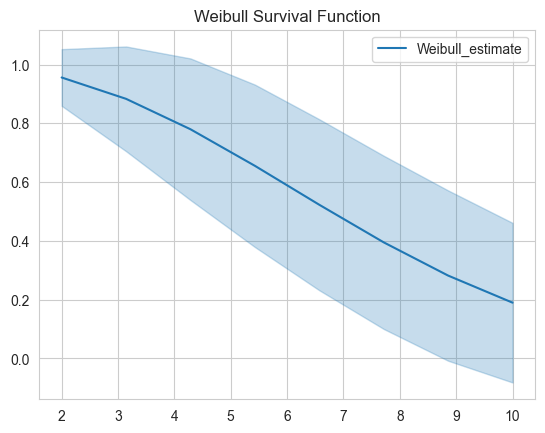

In [7]:
from lifelines import WeibullFitter

wf = WeibullFitter()
wf.fit(durations, event_observed=events)
wf.print_summary()

wf.plot_survival_function()
plt.title("Weibull Survival Function")
plt.show()

**Exponential Model**

Assumes a constant hazard over time (less flexible). Still useful for baseline comparisons.

<lifelines.ExponentialFitter:"Exponential_estimate", fitted with 8 total observations, 2 right-censored observations>
   number of observations = 8
number of events observed = 6
           log-likelihood = -18.84
               hypothesis = lambda_ != 0

---
         coef  se(coef)  coef lower 95%  coef upper 95%
lambda_  8.50      3.47            1.70           15.30

         cmp to    z    p  -log2(p)
lambda_    0.00 2.45 0.01      6.13
---
AIC = 39.68

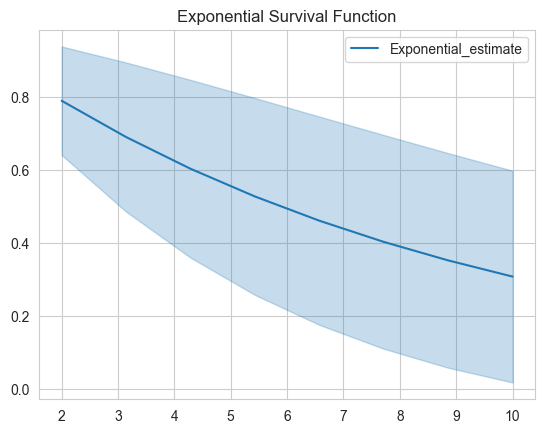

In [8]:
from lifelines import ExponentialFitter

expf = ExponentialFitter()
expf.fit(durations, event_observed=events)
expf.print_summary()
expf.plot_survival_function()
plt.title("Exponential Survival Function")
plt.show()

**Log-Normal and Log-Logistic**

Also available in lifelines, these can be used when survival times are skewed. Example:



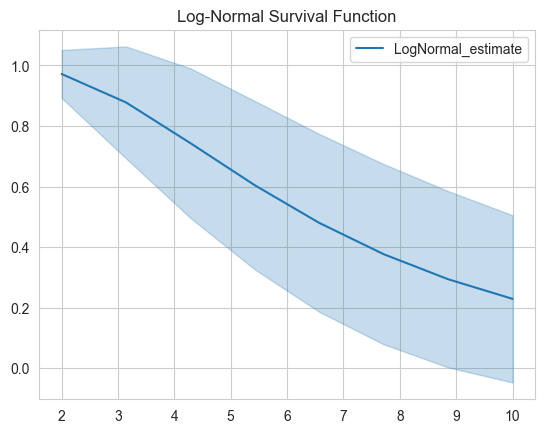

In [9]:
from lifelines import LogNormalFitter

lnf = LogNormalFitter()
lnf.fit(durations, event_observed=events)
lnf.plot_survival_function()
plt.title("Log-Normal Survival Function")
plt.show()

### Survival trees.

These models use recursive partitioning to split the data into subgroups with similar survival behavior. They're easy to interpret and useful for exploratory purposes.

In [10]:
!/Users/guywinfield/PycharmProjects/.turing_venv/bin/python -m pip install scikit-survival


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /Users/guywinfield/PycharmProjects/.turing_venv/bin/python -m pip install --upgrade pip


In [11]:
from sksurv.tree import SurvivalTree
from sksurv.datasets import load_flchain
from sklearn.model_selection import train_test_split

X, y = load_flchain()
X = X.drop(columns=["sex","chapter","mgus"])
y_structured = y  # Structured array with (event, time)

X_train, X_test, y_train, y_test = train_test_split(X, y_structured,
 test_size=0.2, random_state=42)

tree = SurvivalTree(max_depth=3)
tree.fit(X_train, y_train)

,splitter,'best'
,max_depth,3
,min_samples_split,6
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,low_memory,False


In [12]:
X.head()

,age,creatinine,flc.grp,kappa,lambda,sample.yr
0,97.0,1.7,10,5.70,4.860,1997
1,92.0,0.9,1,0.87,0.683,2000
2,94.0,1.4,10,4.36,3.850,1997
3,92.0,1.0,9,2.42,2.220,1996
4,93.0,1.1,6,1.32,1.690,1996


### Random Survival Forests

A robust ensemble model that combines many survival trees to reduce overfitting and boost performance. It can capture non-linear relationships and interactions.

In [13]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(random_state=42)
rsf.fit(X_train, y_train)

surv_fn = rsf.predict_survival_function(X_test.iloc[0:1])

### Gradient Boosted Survival Trees

sksurv also supports survival boosting methods like Gradient Boosted Machines (GBM) via GradientBoostingSurvivalAnalysis.

In [15]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis as gbsa

gbsa.fit(X_train_clean, y_train_clean)

gbsa = gbsa(random_state=42)
gbsa.fit(X_train, y_train)

NameError: name 'X_train_clean' is not defined

## Evaluation metrics

The Concordance Index is the most widely used metric in survival analysis. It measures the ranking quality of the predicted risk scores. In simple terms, it checks whether individuals who died earlier were given higher risk scores than those who died later.

- A value of 0.5 means random prediction
- A value of 1.0 means perfect concordance

In [15]:
from sksurv.metrics import concordance_index_censored

# y_test is a structured array: (event_observed, time)
# risk_scores are the predicted scores (e.g. from a Cox or tree-based model)
risk_scores = -rsf.predict(X_test)
# negative since lower survival = higher risk
ci, _ = concordance_index_censored(y_test["death"], y_test["futime"], risk_scores)

print("C-index:", ci)


ValueError: too many values to unpack (expected 2)

The Brier Score evaluates the accuracy o|f predicted survival probabilities at a specific time 𝑡. The integrated version averages this score across a time interval. Lower values mean better prediction (range: 0 to 1).

In [30]:
from sksurv.metrics import integrated_brier_score
import numpy as np

# Estimate survival functions for test instances
surv_funcs = rsf.predict_survival_function(X_test)

# Convert to 2D array: each row is a survival curve
pred_surv = np.asarray([[fn(t) for t in rsf.event_times_] for fn in surv_funcs])

ibs = integrated_brier_score(y_train, y_test, pred_surv, rsf.event_times_)
print("Integrated Brier Score:", ibs)

AttributeError: 'RandomSurvivalForest' object has no attribute 'event_times_'

Time-dependent AUC. This extends the concept of ROC AUC to survival data. It evaluates how well the model separates low-risk from high-risk subjects at different time points.

In [49]:
from sksurv.metrics import cumulative_dynamic_auc

times = np.percentile(y_train["futime"], np.linspace(10, 90, 5))  # selected time points
auc, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_scores, times)

print("Time-dependent AUCs:", auc)
print("Mean AUC:", np.mean(auc))

Time-dependent AUCs: [0.15638753 0.1682171  0.18709796 0.18592121 0.20911733]
Mean AUC: 0.18134822538516043


# Exercise

In [16]:
import numpy as np
import pandas as pd

from sksurv.datasets import load_flchain
from sksurv.util import Surv

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sksurv.metrics import concordance_index_censored, integrated_brier_score


In [17]:
X, y = load_flchain()


In [18]:
display(X.head())
display(pd.DataFrame(y.tolist(), columns=["event", "time"]).head())


,age,chapter,creatinine,flc.grp,kappa,lambda,mgus,sample.yr,sex
0,97.0,Circulatory,1.7,10,5.70,4.860,no,1997,F
1,92.0,Neoplasms,0.9,1,0.87,0.683,no,2000,F
2,94.0,Circulatory,1.4,10,4.36,3.850,no,1997,F
3,92.0,Circulatory,1.0,9,2.42,2.220,no,1996,F
4,93.0,Circulatory,1.1,6,1.32,1.690,no,1996,F


,event,time
0,True,85.0
1,True,1281.0
2,True,69.0
3,True,115.0
4,True,1039.0


In [19]:
# Censoring Rate
y_df = pd.DataFrame(y.tolist(), columns=["event", "time"])
censor_rate = 1 - y_df["event"].mean()
print(f"Censoring rate: {censor_rate:.3f}  ({censor_rate*100:.1f}%)")

y_df["time"].describe()


Censoring rate: 0.725  (72.5%)


count    7874.000000
mean     3661.042291
std      1432.677330
min         0.000000
25%      2852.000000
50%      4302.000000
75%      4773.000000
max      5215.000000
Name: time, dtype: float64

In [20]:
display(X.describe(include="all").T.head(30))

# Missingness
missing = X.isna().mean().sort_values(ascending=False)
display(missing[missing > 0].head(20))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,7874.0,NaN,NaN,NaN,64.293117,10.462719,50.0,55.0,63.0,72.0,101.0
chapter,2169,16,Circulatory,745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
creatinine,6524.0,NaN,NaN,NaN,1.093516,0.416507,0.4,0.9,1.0,1.2,10.8
flc.grp,7874,10,3,820,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kappa,7874.0,NaN,NaN,NaN,1.430881,0.896774,0.01,0.96,1.27,1.68,20.5
lambda,7874.0,NaN,NaN,NaN,1.702624,1.030732,0.04,1.2,1.51,1.92,26.6
mgus,7874,2,no,7759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sample.yr,7874,9,1996,3491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,7874,2,F,4350,NaN,NaN,NaN,NaN,NaN,NaN,NaN


chapter       0.724536
creatinine    0.171450
dtype: float64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                     # 👈 keep y as-is
    test_size=0.25,
    random_state=42,
    stratify=y_df["event"]
)


In [22]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        drop="first"
    ))
])


numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ]
)


In [23]:
def evaluate_survival_model(name, model, X_train, y_train, X_test, y_test, times=None):
    # Fit
    model.fit(X_train, y_train)

    # ---- C-index (needs a risk score: higher risk = earlier event) ----
    # Many sksurv models implement predict() as risk score
    if hasattr(model, "predict"):
        risk_scores = model.predict(X_test)
    else:
        risk_scores = np.zeros(len(X_test))  # fallback

    cidx = concordance_index_censored(y_test["death"], y_test["futime"], risk_scores)[0]

    # ---- IBS (needs survival functions) ----
    if times is None:
        # Choose a grid inside the observed test time range
        t_min = max(1.0, np.percentile(y_test["futime"], 5))
        t_max = np.percentile(y_test["futime"], 95)
        times = np.linspace(t_min, t_max, 100)

    if hasattr(model, "predict_survival_function"):
        surv_fns = model.predict_survival_function(X_test)

        # Convert list of callables -> matrix [n_samples, n_times]
        surv_probs = np.row_stack([fn(times) for fn in surv_fns])

        ibs = integrated_brier_score(y_train, y_test, surv_probs, times)
    else:
        ibs = np.nan

    return {"Model": name, "C-index": cidx, "IBS": ibs, "times": times}


In [24]:
print("y fields:", y.dtype.names)


y fields: ('death', 'futime')


In [25]:
from sksurv.nonparametric import kaplan_meier_estimator

# KM curve from TRAIN
ytr = y_train
event, time = ytr["death"], ytr["futime"]
km_time, km_surv = kaplan_meier_estimator(event, time)

# Build a callable survival function via interpolation
def km_fn(t):
    return np.interp(t, km_time, km_surv, left=1.0, right=km_surv[-1])

# Evaluate IBS on TEST
times = np.linspace(np.percentile(y_test["futime"], 5), np.percentile(y_test["futime"], 95), 100)
surv_probs = np.tile(km_fn(times), (len(y_test), 1))
ibs_km = integrated_brier_score(y_train, y_test, surv_probs, times)

# C-index baseline ~ 0.5 (constant risk)
risk_scores = np.zeros(len(y_test))
cidx_km = concordance_index_censored(y_test["death"], y_test["futime"], risk_scores)[0]

km_result = {"Model": "Kaplan–Meier", "C-index": cidx_km, "IBS": ibs_km}
km_result


{'Model': 'Kaplan–Meier',
 'C-index': np.float64(0.5),
 'IBS': np.float64(0.1419419083836177)}

In [26]:
from sksurv.linear_model import CoxPHSurvivalAnalysis

cox = Pipeline(steps=[
    ("prep", preprocess),
    ("model", CoxPHSurvivalAnalysis())
])

cox_result = evaluate_survival_model("CoxPH", cox, X_train, y_train, X_test, y_test)
cox_result


/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sksurv/linear_model/coxph.py:200: RuntimeWarning: overflow encountered in exp
  risk_set += np.exp(xw[k])
/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sksurv/linear_model/coxph.py:197: RuntimeWarning: overflow encountered in exp
  risk_set2 += np.exp(xw[k])
/var/folders/kn/24kjgmss2yzfjngp_zf6x8vr0000gn/T/ipykernel_1223/2333936402.py:25: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  surv_probs = np.row_stack([fn(times) for fn in surv_fns])


{'Model': 'CoxPH',
 'C-index': np.float64(0.8820468219795261),
 'IBS': np.float64(0.07700263451042885),
 'times': array([ 527.        ,  571.93535354,  616.87070707,  661.80606061,
         706.74141414,  751.67676768,  796.61212121,  841.54747475,
         886.48282828,  931.41818182,  976.35353535, 1021.28888889,
        1066.22424242, 1111.15959596, 1156.09494949, 1201.03030303,
        1245.96565657, 1290.9010101 , 1335.83636364, 1380.77171717,
        1425.70707071, 1470.64242424, 1515.57777778, 1560.51313131,
        1605.44848485, 1650.38383838, 1695.31919192, 1740.25454545,
        1785.18989899, 1830.12525253, 1875.06060606, 1919.9959596 ,
        1964.93131313, 2009.86666667, 2054.8020202 , 2099.73737374,
        2144.67272727, 2189.60808081, 2234.54343434, 2279.47878788,
        2324.41414141, 2369.34949495, 2414.28484848, 2459.22020202,
        2504.15555556, 2549.09090909, 2594.02626263, 2638.96161616,
        2683.8969697 , 2728.83232323, 2773.76767677, 2818.7030303 ,
   

In [27]:
try:
    from sksurv.linear_model import WeibullAFTFitter

    weibull = Pipeline(steps=[
        ("prep", preprocess),
        ("model", WeibullAFTFitter())
    ])

    weibull_result = evaluate_survival_model("Weibull AFT", weibull, X_train, y_train, X_test, y_test)
    weibull_result

except Exception as e:
    print("WeibullAFTFitter not available (or failed to import) in your environment.")
    print("Error:", repr(e))
    weibull_result = {"Model": "Weibull AFT", "C-index": np.nan, "IBS": np.nan}


WeibullAFTFitter not available (or failed to import) in your environment.
Error: ImportError("cannot import name 'WeibullAFTFitter' from 'sksurv.linear_model' (/Users/guywinfield/PycharmProjects/.turing_venv/lib/python3.13/site-packages/sksurv/linear_model/__init__.py)")


In [28]:
from sksurv.tree import SurvivalTree

tree = Pipeline(steps=[
    ("prep", preprocess),
    ("model", SurvivalTree(random_state=42))
])

tree_result = evaluate_survival_model("Survival Tree", tree, X_train, y_train, X_test, y_test)
tree_result


/var/folders/kn/24kjgmss2yzfjngp_zf6x8vr0000gn/T/ipykernel_1223/2333936402.py:25: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  surv_probs = np.row_stack([fn(times) for fn in surv_fns])


{'Model': 'Survival Tree',
 'C-index': np.float64(0.8375304162270572),
 'IBS': np.float64(0.10131646349484565),
 'times': array([ 527.        ,  571.93535354,  616.87070707,  661.80606061,
         706.74141414,  751.67676768,  796.61212121,  841.54747475,
         886.48282828,  931.41818182,  976.35353535, 1021.28888889,
        1066.22424242, 1111.15959596, 1156.09494949, 1201.03030303,
        1245.96565657, 1290.9010101 , 1335.83636364, 1380.77171717,
        1425.70707071, 1470.64242424, 1515.57777778, 1560.51313131,
        1605.44848485, 1650.38383838, 1695.31919192, 1740.25454545,
        1785.18989899, 1830.12525253, 1875.06060606, 1919.9959596 ,
        1964.93131313, 2009.86666667, 2054.8020202 , 2099.73737374,
        2144.67272727, 2189.60808081, 2234.54343434, 2279.47878788,
        2324.41414141, 2369.34949495, 2414.28484848, 2459.22020202,
        2504.15555556, 2549.09090909, 2594.02626263, 2638.96161616,
        2683.8969697 , 2728.83232323, 2773.76767677, 2818.70303

In [ ]:
from sksurv.ensemble import RandomSurvivalForest

rsf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomSurvivalForest(
        n_estimators=300,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    ))
])

rsf_result = evaluate_survival_model("Random Survival Forest", rsf, X_train, y_train, X_test, y_test)
rsf_result


In [ ]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

gbst = Pipeline(steps=[
    ("prep", preprocess),
    ("model", GradientBoostingSurvivalAnalysis(random_state=42))
])

gbst_result = evaluate_survival_model("Gradient Boosted Survival Trees", gbst, X_train, y_train, X_test, y_test)
gbst_result


In [ ]:
results = pd.DataFrame([
    km_result, cox_result, weibull_result, tree_result, rsf_result, gbst_result
])

# Higher C-index is better, lower IBS is better
display(results.sort_values(["C-index", "IBS"], ascending=[False, True]))


In [ ]:
from sklearn.metrics import make_scorer

def cindex_scorer(estimator, X_val, y_val):
    # risk score
    risk = estimator.predict(X_val)
    return concordance_index_censored(y_val["death"], y_val["futime"], risk)[0]


In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 1) CoxPH tuning
cox_tune = GridSearchCV(
    estimator=cox,
    param_grid={
        # CoxPH has limited params; if you want penalization you'd use CoxnetSurvivalAnalysis instead.
    },
    scoring=cindex_scorer,
    cv=cv,
    n_jobs=-1
)
cox_tune.fit(X_train, y_train)
best_cox = cox_tune.best_estimator_
print("Best CoxPH CV C-index:", cox_tune.best_score_)

# 2) RSF tuning
rsf_tune = GridSearchCV(
    estimator=rsf,
    param_grid={
        "model__n_estimators": [300, 600],
        "model__max_features": ["sqrt", 0.5],
        "model__min_samples_leaf": [3, 5, 10],
        "model__min_samples_split": [5, 10, 20],
    },
    scoring=cindex_scorer,
    cv=cv,
    n_jobs=-1
)
rsf_tune.fit(X_train, y_train)
best_rsf = rsf_tune.best_estimator_
print("Best RSF CV C-index:", rsf_tune.best_score_)
print("Best RSF params:", rsf_tune.best_params_)

# 3) GBST tuning
gbst_tune = GridSearchCV(
    estimator=gbst,
    param_grid={
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__n_estimators": [200, 500, 1000],
        "model__max_depth": [1, 2, 3],
        "model__min_samples_split": [2, 10, 30],
    },
    scoring=cindex_scorer,
    cv=cv,
    n_jobs=-1
)
gbst_tune.fit(X_train, y_train)
best_gbst = gbst_tune.best_estimator_
print("Best GBST CV C-index:", gbst_tune.best_score_)
print("Best GBST params:", gbst_tune.best_params_)
